# TRABAJO MACHINE LEARNING - <Biofísica>

# Trabajo realizado por:
## - Xandre Álvarez González
## - Roi Casal Blanco

In [63]:
import numpy as np  
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets, preprocessing, linear_model, model_selection, metrics
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, r2_score, classification_report

# 1. IMPORTAMOS LOS DATOS

Nuestra base de datos será la siguiente:

https://www.kaggle.com/datasets/nathanlauga/nba-games

In [64]:
df = pd.read_csv("games.csv",sep=',')
print(df)

      GAME_DATE_EST   GAME_ID GAME_STATUS_TEXT  HOME_TEAM_ID  VISITOR_TEAM_ID  \
0        2022-12-22  22200477            Final    1610612740       1610612759   
1        2022-12-22  22200478            Final    1610612762       1610612764   
2        2022-12-21  22200466            Final    1610612739       1610612749   
3        2022-12-21  22200467            Final    1610612755       1610612765   
4        2022-12-21  22200468            Final    1610612737       1610612741   
...             ...       ...              ...           ...              ...   
26646    2014-10-06  11400007            Final    1610612737       1610612740   
26647    2014-10-06  11400004            Final    1610612741       1610612764   
26648    2014-10-06  11400005            Final    1610612747       1610612743   
26649    2014-10-05  11400002            Final    1610612761       1610612758   
26650    2014-10-04  11400001            Final    1610612748       1610612740   

       SEASON  TEAM_ID_home

In [65]:
df.shape

(26651, 21)

In [66]:
df.describe()

,GAME_ID,HOME_TEAM_ID,VISITOR_TEAM_ID,SEASON,TEAM_ID_home,PTS_home,FG_PCT_home,FT_PCT_home,FG3_PCT_home,AST_home,REB_home,TEAM_ID_away,PTS_away,FG_PCT_away,FT_PCT_away,FG3_PCT_away,AST_away,REB_away,HOME_TEAM_WINS
count,2.665100e+04,2.665100e+04,2.665100e+04,26651.000000,2.665100e+04,26552.000000,26552.000000,26552.000000,26552.000000,26552.000000,26552.000000,2.665100e+04,26552.000000,26552.000000,26552.000000,26552.000000,26552.000000,26552.000000,26651.000000
mean,2.175487e+07,1.610613e+09,1.610613e+09,2012.113879,1.610613e+09,103.455898,0.460735,0.760377,0.356023,22.823441,43.374284,1.610613e+09,100.639876,0.449732,0.758816,0.349489,21.496271,42.113249,0.587032
std,5.570189e+06,8.638670e+00,8.659299e+00,5.587031,8.638670e+00,13.283370,0.056676,0.100677,0.111164,5.193308,6.625769,8.659299e+00,13.435868,0.055551,0.103429,0.109441,5.160596,6.533039,0.492376
min,1.030000e+07,1.610613e+09,1.610613e+09,2003.000000,1.610613e+09,36.000000,0.250000,0.143000,0.000000,6.000000,15.000000,1.610613e+09,33.000000,0.244000,0.143000,0.000000,4.000000,19.000000,0.000000
25%,2.070001e+07,1.610613e+09,1.610613e+09,2007.000000,1.610613e+09,94.000000,0.422000,0.697000,0.286000,19.000000,39.000000,1.610613e+09,91.000000,0.412000,0.692000,0.278000,18.000000,38.000000,0.000000
50%,2.120076e+07,1.610613e+09,1.610613e+09,2012.000000,1.610613e+09,103.000000,0.460000,0.765000,0.357000,23.000000,43.000000,1.610613e+09,100.000000,0.449000,0.765000,0.350000,21.000000,42.000000,1.000000
75%,2.180005e+07,1.610613e+09,1.610613e+09,2017.000000,1.610613e+09,112.000000,0.500000,0.833000,0.429000,26.000000,48.000000,1.610613e+09,110.000000,0.487000,0.833000,0.419000,25.000000,46.000000,1.000000
max,5.210021e+07,1.610613e+09,1.610613e+09,2022.000000,1.610613e+09,168.000000,0.684000,1.000000,1.000000,50.000000,72.000000,1.610613e+09,168.000000,0.687000,1.000000,1.000000,46.000000,81.000000,1.000000


Esto nos sirve para ver un resumen inicial de los datos que tenemos.

A grandes rasgos, se trata de una base de datos de partidos de la liga estaunidense de baloncesto masculina (NBA), que recoge los datos de puntos, asistencias, rebotes, porcentages de tiro (de campo, libre y de triple), tanto del equipo local como del visitante; desde el año 2003, al 2022. También recoge en la última columna si gano el local (1), o el visitante (0).

# 2. DATA CLEANING Y PRE-PROCESING

Primero borramos columnas que no nos aportan información importante, como el ID del partido,  el ID de los equipos, o la fecha.

In [67]:
df = df.drop(columns=['GAME_DATE_EST', 'GAME_ID', 'HOME_TEAM_ID', 'VISITOR_TEAM_ID', 'TEAM_ID_home', 'TEAM_ID_away'])

In [68]:
print(df)

      GAME_STATUS_TEXT  SEASON  PTS_home  FG_PCT_home  FT_PCT_home  \
0                Final    2022     126.0        0.484        0.926   
1                Final    2022     120.0        0.488        0.952   
2                Final    2022     114.0        0.482        0.786   
3                Final    2022     113.0        0.441        0.909   
4                Final    2022     108.0        0.429        1.000   
...                ...     ...       ...          ...          ...   
26646            Final    2014      93.0        0.419        0.821   
26647            Final    2014      81.0        0.338        0.719   
26648            Final    2014      98.0        0.448        0.682   
26649            Final    2014      99.0        0.440        0.771   
26650            Final    2014      86.0        0.431        0.679   

       FG3_PCT_home  AST_home  REB_home  PTS_away  FG_PCT_away  FT_PCT_away  \
0             0.382      25.0      46.0     117.0        0.478        0.815   
1

Ahora hacemos que solo los partidos finalizados cuenten:

In [69]:
df = df[df['GAME_STATUS_TEXT'] == 'Final']

Una vez hecho esto, eliminamos esta columna.

In [70]:
df = df.drop(columns=['GAME_STATUS_TEXT'])

Ahora eliminamos las filas con valores NAN

In [71]:
df.dropna(axis=0, how='any', inplace=True)


Vemos como esto ya nos elimina bastantes filas que no servían.

# 3. ANÁLISIS DE REGRESIÓN

Es fácil intuir que habrá varias variables que estarán relacionadas, como son el número de puntos y el porcentage de acierto de tiro, o las asistencias, por lo que podemos realizar un análisis de regresión para predecir el comportamiento de la variable dependiente en función de la independiente.

Podemos intentar usar todos los datos de dos variables que deberían relacionarse, como son el porcentaje de tiro del local (eje x), y los puntos del equipo local (eje y)

R^2: 0.4384627384477656


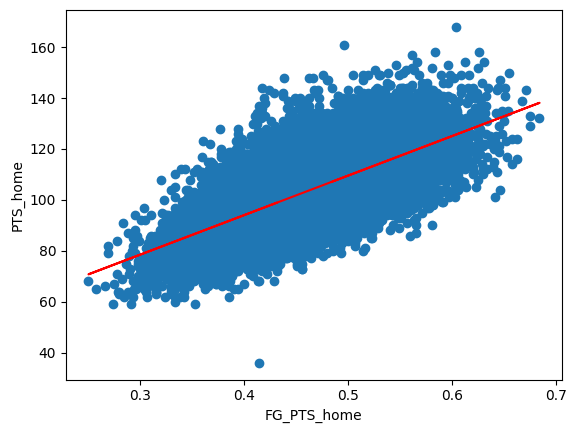

In [72]:
FG_PTS_home = df["FG_PCT_home"].values.reshape(-1,1)
PTS_home = df["PTS_home"].values.reshape(-1, 1)

reg = LinearRegression().fit(FG_PTS_home, PTS_home)
y_hat = reg.predict(FG_PTS_home)

r2 = reg.score(FG_PTS_home, PTS_home)

plt.scatter(FG_PTS_home, PTS_home)
plt.plot(FG_PTS_home, y_hat,"r-")
plt.ylabel('PTS_home')
plt.xlabel('FG_PTS_home')

print("R^2:", r2)

Al tener un grán número de datos que rondan el mismo valor, no creemos que una regresión lineal se ajuste a nuestros datos (el valor $r^2$ muy bajo). A pesar de ver claramente como los datos están relacionados, no podemos asegurar que se relacionen de forma lineal o polinómica.

Vamos a intentar reducir el número de datos seleccionando solo una temporada (2012, por ejemplo).

R^2: 0.49011081845984183


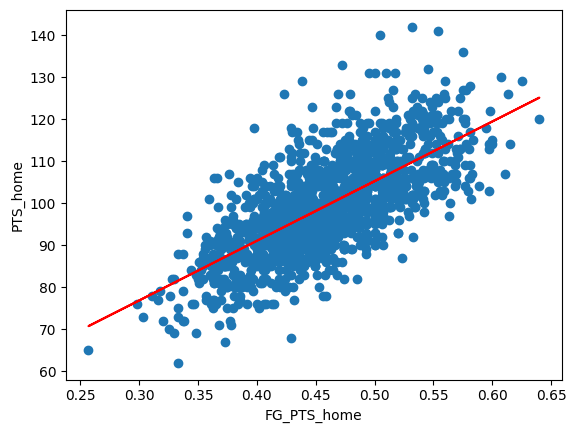

In [73]:
S_2020 = df[df["SEASON"] == 2012]

FG_PTS_home = S_2020["FG_PCT_home"].values.reshape(-1,1)
PTS_home = S_2020["PTS_home"].values.reshape(-1, 1)

reg = LinearRegression().fit(FG_PTS_home, PTS_home)
y_hat = reg.predict(FG_PTS_home)

r2 = reg.score(FG_PTS_home, PTS_home)

plt.scatter(FG_PTS_home, PTS_home)
plt.plot(FG_PTS_home, y_hat,"r-")
plt.ylabel('PTS_home')
plt.xlabel('FG_PTS_home')

print("R^2:", r2)

Vemos que se podría adecuar algo más, pero aun así sigue sin tener el comportamiento que esperaríamos de una regresión lineal ($r^2$ sigue siendo muy bajo). Tampoco creemos que se ajuste a algún tipo de regresión polinómica, exponencial o logarítmica, por lo que no vamos a continuar con este apartado, ya que no esperamos resultados positivos.

# 4. CORRELACIÓN ENTRE LOS DATOS.

4.1 MAPA DE CALOR.

Para ver la relación entre los distintos valores del partido (pts, asist, reb, FG...), utilizaremos la función datos_num.corr(). La función .corr() crea una nueva tabla con valores de -1 a 1, que representan como están correlacionados los valores de la tabla original, siendo -1 inversamente relacionados, 0 no relacionados, y 1, fuertemente relacionados.

Representaremos esto en un mapa de calor. Para este punto utilizaremos una base de datos sin la temporada, ya que no nos interesa esta columna.

<Axes: >

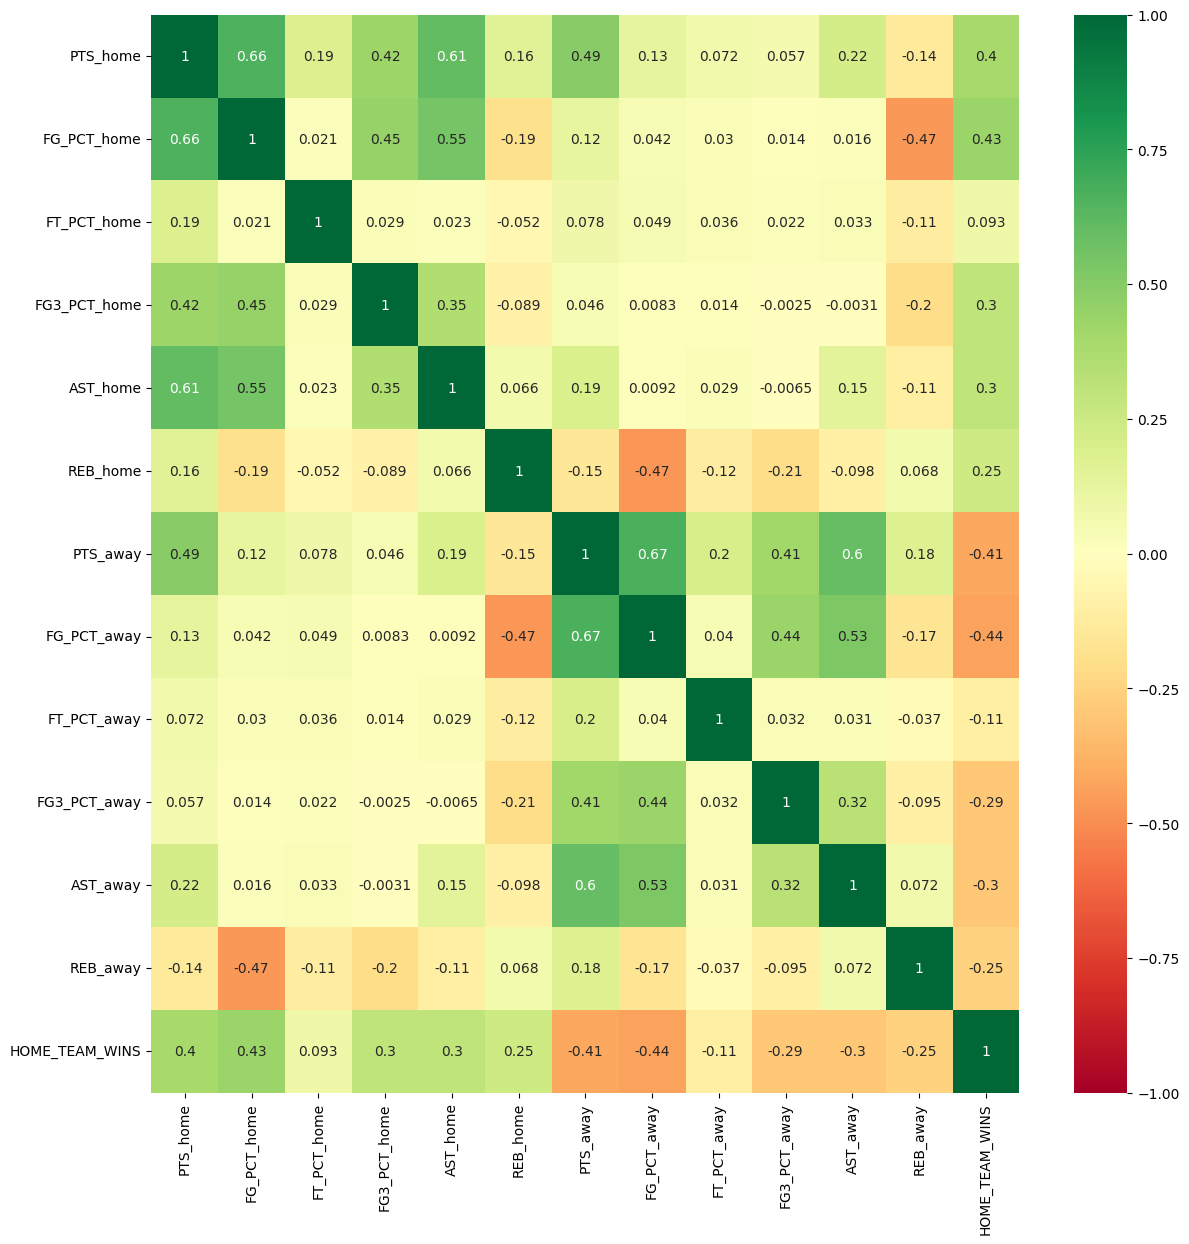

In [74]:
datos_num = df.drop(columns=['SEASON'])

relacion_datos = datos_num.corr()

plt.figure(figsize=(14,14))
sns.heatmap(relacion_datos, annot=True, cmap='RdYlGn', vmin=-1, vmax=1)

Vemos fácilmente que los valores mas correlacionados son el número de puntos, y el porcentaje de acierto, tanto del local como del visitante. 

También vemos que los rebotes de un equipo están inversamente correlacionados con el porcentaje de acierto del otro equipo, lo cual tiene sentido, porque si el rival acierta el tiro, no hay opción de rebote.

4.2 MÁQUINAS DE VECTORES DE SOPORTE.

Nuestra SVM aprende a distinguir entre victoria local (1) y visitante (0), buscando una frontera que separe los partidos según las diferencias de estadísticas (ast, rebotes, etc.).

Como está claro que el equipo que meta más puntos gana, vamos a eliminar las dos columnas de pts, para centrarnos simplemente en el resto de datos.

In [75]:
datos_num = datos_num.drop(columns=['PTS_home', 'PTS_away'])
print(datos_num)

       FG_PCT_home  FT_PCT_home  FG3_PCT_home  AST_home  REB_home  \
0            0.484        0.926         0.382      25.0      46.0   
1            0.488        0.952         0.457      16.0      40.0   
2            0.482        0.786         0.313      22.0      37.0   
3            0.441        0.909         0.297      27.0      49.0   
4            0.429        1.000         0.378      22.0      47.0   
...            ...          ...           ...       ...       ...   
26646        0.419        0.821         0.421      24.0      50.0   
26647        0.338        0.719         0.381      18.0      40.0   
26648        0.448        0.682         0.500      29.0      45.0   
26649        0.440        0.771         0.333      21.0      30.0   
26650        0.431        0.679         0.333      18.0      42.0   

       FG_PCT_away  FT_PCT_away  FG3_PCT_away  AST_away  REB_away  \
0            0.478        0.815         0.321      23.0      44.0   
1            0.561        0.765  

Definimos la columna de HOME_TEAM_WINS, como nuestro valor *y*, es decir, el resultado, mientras que, el resto de datos, serán las características que llevarán a este resultado

In [76]:
target_col = "HOME_TEAM_WINS"   # 1 = victoria local, 0 = visitante
X = datos_num.drop(columns=[target_col])
y = datos_num[target_col].astype(int)

Escalamos los datos:

In [77]:
X_scaled = preprocessing.scale(X)

Para ejemplificar, graficaré las asistencias locales y visitantes.

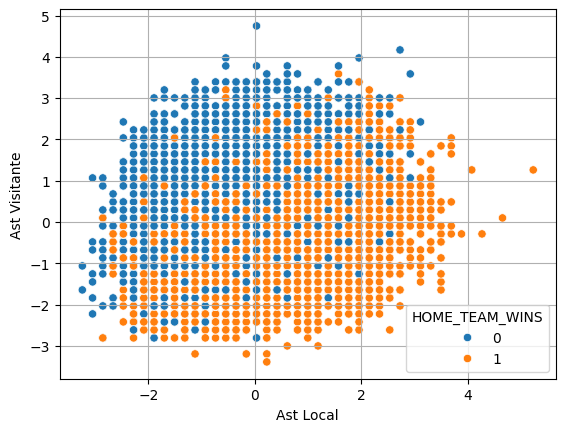

In [78]:
# Gráfica de 2 columnas
sns.scatterplot(x=X_scaled[:, 3], y=X_scaled[:, 8], hue=y) #size, style=data
plt.xlabel('Ast Local')
plt.ylabel('Ast Visitante')
plt.grid(True)
plt.show()

Utilizamos la validación cruzada.

La validación cruzada es una forma de comprobar qué tan bien funciona un modelo sin depender de una sola división de los datos, es decir, dividiendo el dataset en varias partes, en lugar de entrenar con un grupo fijo, y probar con otro.

In [79]:
alpha_vals = np.arange(1e-15,1,0.005)  # valores desde 1e-7 a 1e-2
val_scores = []

for a in alpha_vals:
    model = linear_model.SGDClassifier(
        loss="hinge", penalty="l2", alpha=a,)
    scores = model_selection.cross_val_score(
        model, X, y, cv=5, scoring="accuracy")
    val_scores.append(scores.mean())

val_scores = np.array(val_scores)


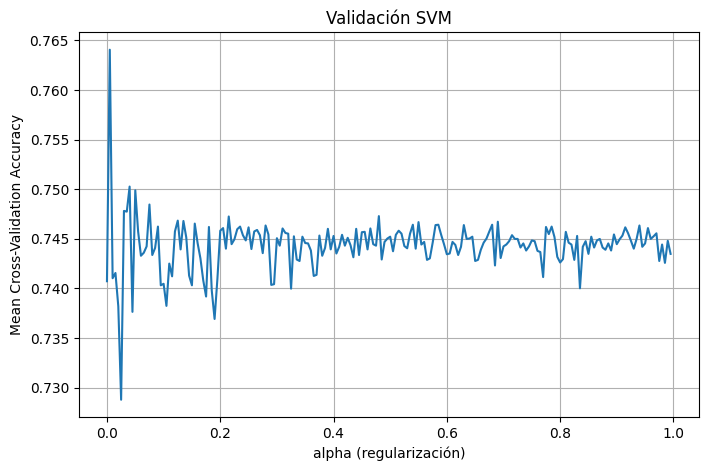

In [80]:
plt.figure(figsize=(8, 5))
plt.plot(alpha_vals, val_scores) 
plt.xlabel("alpha (regularización)")
plt.ylabel('Mean Cross-Validation Accuracy')
plt.title("Validación SVM")
plt.grid(True)
plt.show()

Buscamos el valor alpha, que maximice el rendimiento del modelo (su precisión):

In [81]:
best_alpha = alpha_vals[np.argmax(val_scores)]
print(f"\nMejor alpha: {best_alpha:.2e} con accuracy medio = {max(val_scores):.4f}")


Mejor alpha: 5.00e-03 con accuracy medio = 0.7640


Ahora utilizaremos este modelo de alpha para entrenar nuestro modelo:


Accuracy en test: 0.8360

Matriz de confusión:
[[1704  478]
 [ 393 2736]]


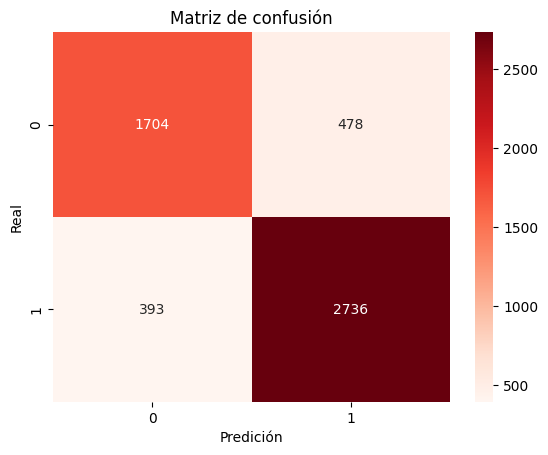

In [82]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

model_hold = linear_model.SGDClassifier(
    loss="hinge", penalty="l2", alpha=best_alpha,
)
model_hold.fit(X_train, y_train)

y_pred = model_hold.predict(X_test)

print(f"\nAccuracy en test: {model_hold.score(X_test, y_test):.4f}")
print("\nMatriz de confusión:")
print(metrics.confusion_matrix(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds")
plt.xlabel("Predición")
plt.ylabel("Real")
plt.title("Matriz de confusión")
plt.show()

Los resultados muestran un porcentaje de acierto de alrededor del 83%. La gráfica de la matriz de confusión nos señala que se predicen mejor las victorias que las derrotas.

Ahora vamos a volver a realizar la gráfica de las asistencias, con nuestro valor de alpha.

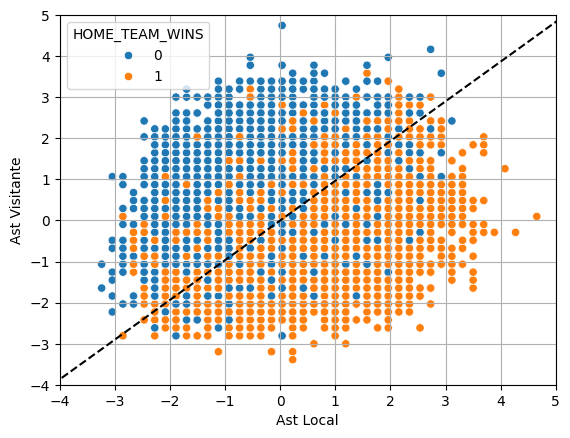

In [83]:
slope = model_hold.coef_[0,8]/-model_hold.coef_[0,3]
x1 = np.arange(-10,10,0.5)
y1 = slope*x1
sns.scatterplot(x=X_scaled[:, 3], y=X_scaled[:, 8], hue=y)
plt.plot(x1,y1,'--k')
plt.xlim(-4,5)
plt.ylim(-4,5)
plt.xlabel('Ast Local')
plt.ylabel('Ast Visitante')
plt.grid(True)
plt.show()

# 5. DECISION TREE

Vamos a hacer ahora un árbol de decisiones que nos permita predecir el resultado final del partido. Un árbol de decisiones es un modelo de aprendizaje supervisada que predice resultados basándose en una serie de reglas autométicas. Para ello divide nuestra muestra de datos en función de sus características hasta llegar a una decisión final, que en nuestro caso será si el equipo local ganó o no su partido

En primer lugar debemos eliminar las columnas que no necesitemos como son el estado del partido (ya sabemos que todos están finalizados), la temporada en la que se jugó y también necesitamos eliminar o bien los puntos locales o bien los visitantes, ya que si no nuestro árbol solo compararía quien tiene más puntos y nos haría una predicción trivial. Por eso haremos dos árboles, uno conociendo los puntos de local y otro los puntos visitantes.

In [84]:
df1 = df.drop(columns=['SEASON', 'PTS_away'])
df2 = df.drop(columns=['SEASON', 'PTS_home'])
print(df1)
print(df2)

       PTS_home  FG_PCT_home  FT_PCT_home  FG3_PCT_home  AST_home  REB_home  \
0         126.0        0.484        0.926         0.382      25.0      46.0   
1         120.0        0.488        0.952         0.457      16.0      40.0   
2         114.0        0.482        0.786         0.313      22.0      37.0   
3         113.0        0.441        0.909         0.297      27.0      49.0   
4         108.0        0.429        1.000         0.378      22.0      47.0   
...         ...          ...          ...           ...       ...       ...   
26646      93.0        0.419        0.821         0.421      24.0      50.0   
26647      81.0        0.338        0.719         0.381      18.0      40.0   
26648      98.0        0.448        0.682         0.500      29.0      45.0   
26649      99.0        0.440        0.771         0.333      21.0      30.0   
26650      86.0        0.431        0.679         0.333      18.0      42.0   

       FG_PCT_away  FT_PCT_away  FG3_PCT_away  AST_

Creamos entonces nuestro árbol de decisiones declarando las variables X (variables a estudiar para predecir si ganó el equipo local o no) y la variable Y (resultado del equipo local).


In [85]:
X1 = df1[['PTS_home', 'FG_PCT_home', 'FT_PCT_home', 'FG3_PCT_home', 
        'AST_home', 'REB_home',
        'FG_PCT_away', 'FT_PCT_away', 'FG3_PCT_away', 
        'AST_away', 'REB_away']]
y1 = df1['HOME_TEAM_WINS']

X2 = df2[['PTS_away', 'FG_PCT_home', 'FT_PCT_home', 'FG3_PCT_home', 
        'AST_home', 'REB_home',
        'FG_PCT_away', 'FT_PCT_away', 'FG3_PCT_away', 
        'AST_away', 'REB_away']]
y2 = df2['HOME_TEAM_WINS']

Ahora necesitamos "entrenar" nuestro Decision Tree: para eso leeremos un 80% de los datos de nuestro dataset y a continuación intentaremos predecir el 20% restante, comparando nuestros resultados obtenidos con los datos reales.

In [86]:
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)
tree1 = DecisionTreeClassifier(criterion='entropy', random_state=42, max_depth=3)
tree1.fit(X1_train, y1_train)

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)
tree2 = DecisionTreeClassifier(criterion='entropy', random_state=42, max_depth=3)
tree2.fit(X2_train, y2_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Una vez entrenado, hacemos las predicciones y vemos la correlación entre los datos obtenidos y los originales:

Accuracy 1: 0.774242138956882
Matriz de confusión 1:
 [[1624  560]
 [ 639 2488]]


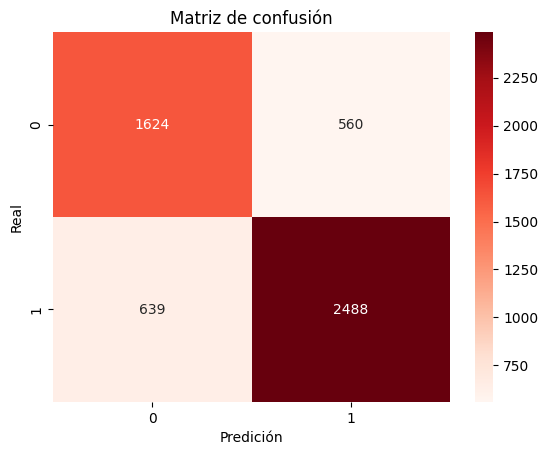

Accuracy 2: 0.7531538316701186
Matriz de confusión 2:
 [[1412  772]
 [ 539 2588]]


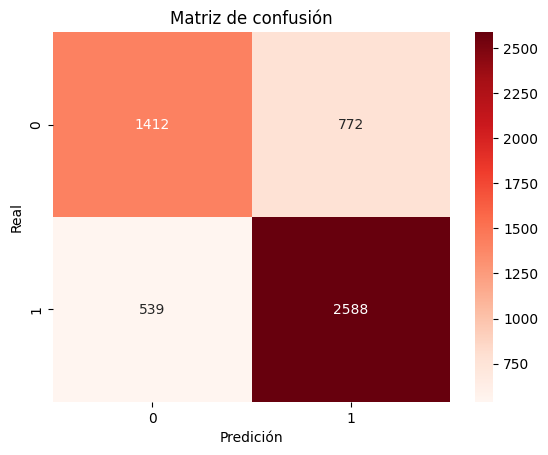

In [87]:
y1_pred = tree1.predict(X1_test)
accuracy1 = accuracy_score(y1_test, y1_pred)
cm1 = confusion_matrix(y1_test, y1_pred)
print("Accuracy 1:", accuracy1)
print("Matriz de confusión 1:\n", cm1)
sns.heatmap(cm1, annot=True, fmt="d", cmap="Reds")
plt.xlabel("Predición")
plt.ylabel("Real")
plt.title("Matriz de confusión")
plt.show()


y2_pred = tree2.predict(X2_test)
accuracy2 = accuracy_score(y2_test, y2_pred)
cm2 = confusion_matrix(y2_test, y2_pred)
print("Accuracy 2:", accuracy2)
print("Matriz de confusión 2:\n", cm2)
sns.heatmap(cm2, annot=True, fmt="d", cmap="Reds")
plt.xlabel("Predición")
plt.ylabel("Real")
plt.title("Matriz de confusión")
plt.show()

Con las matrices de confusión se observa como hacierta mejor la victoria del equipo que conoce los puntos anotados. Esto es, en el primer caso conoce la puntuación del equipo local y predice mejor la victoria del local que la derrota. Por otra parte en el segundo gráfico conoce los datos de anotación del equipo visitante y predice mejor la derrota del local (o victoria del visitante) que la victoria.

Por último visualizamos el Decision Tree:

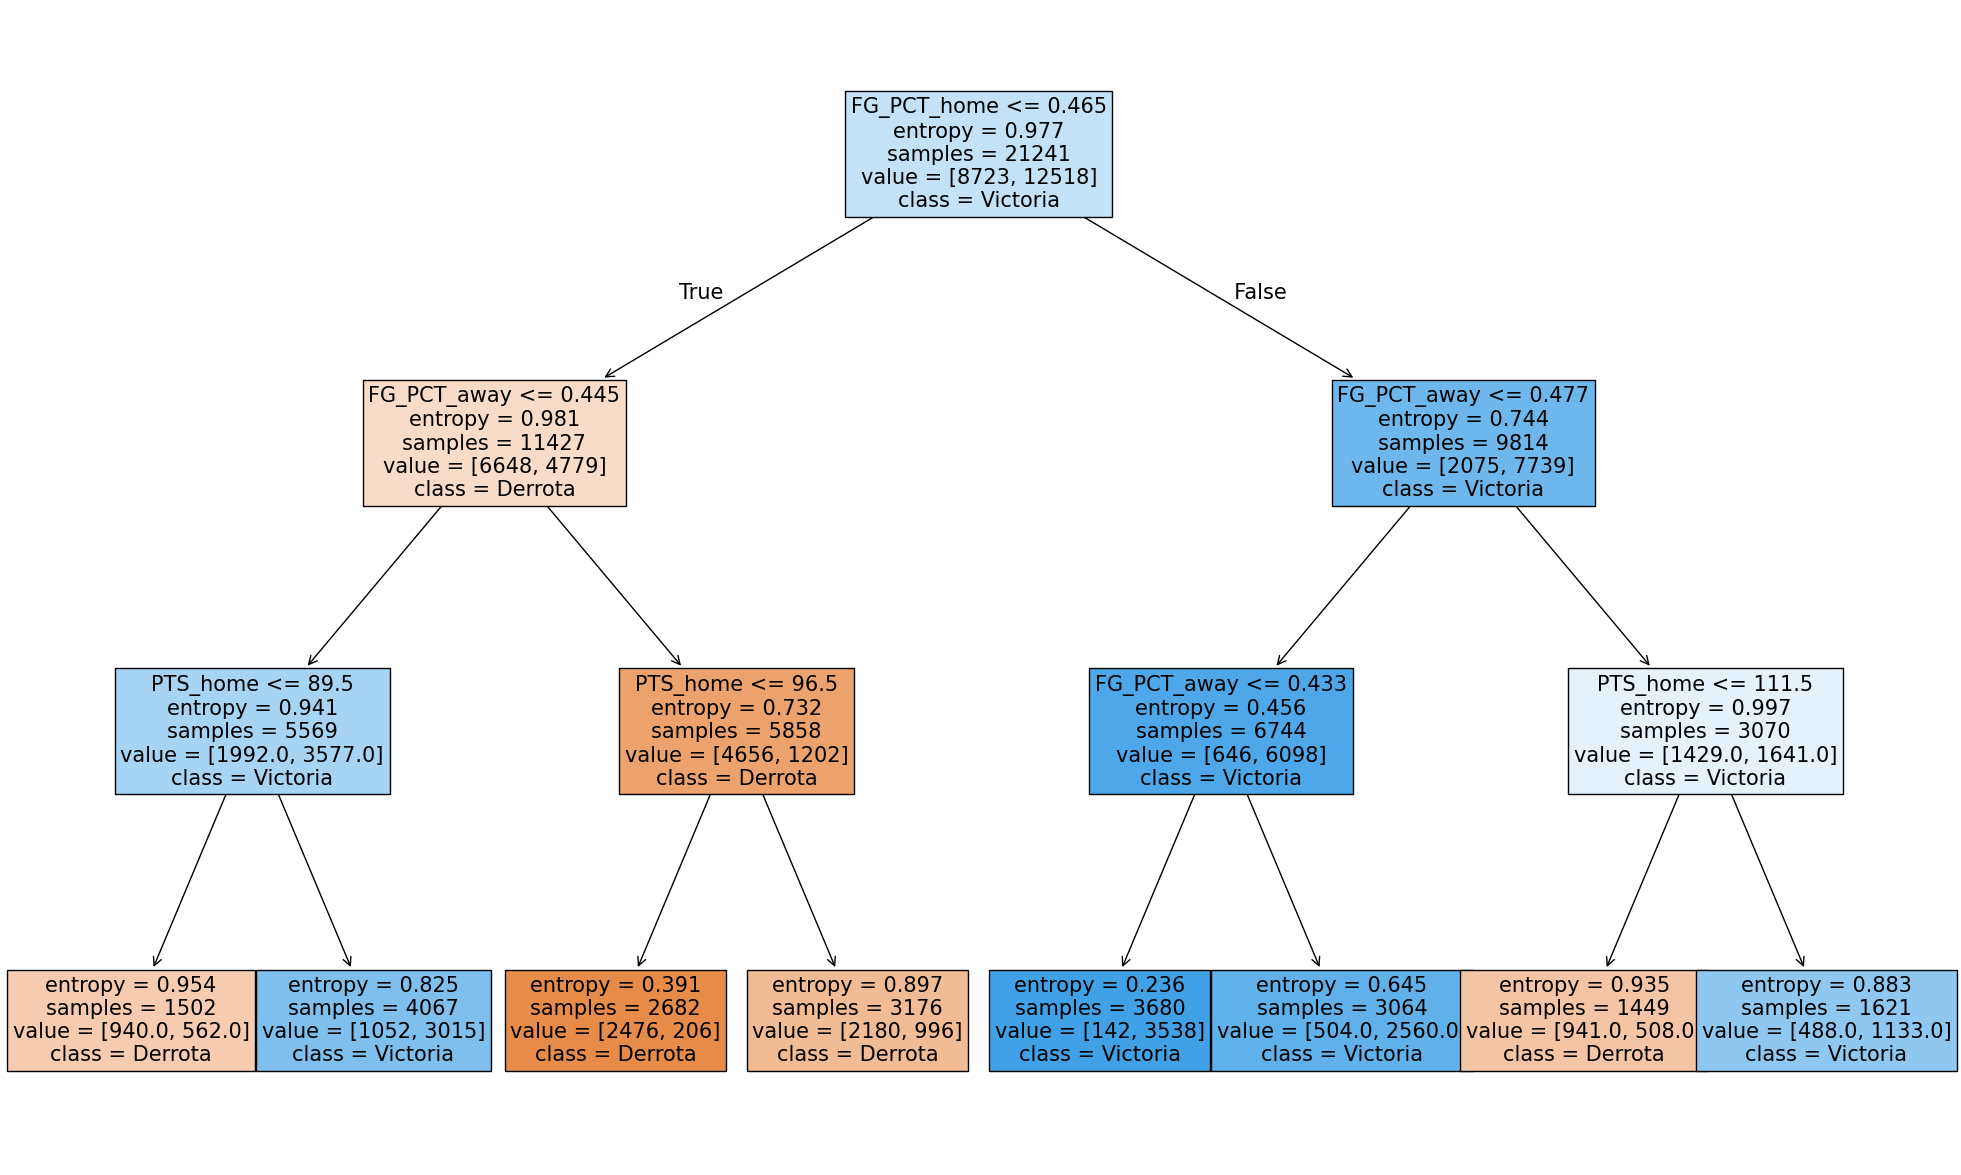

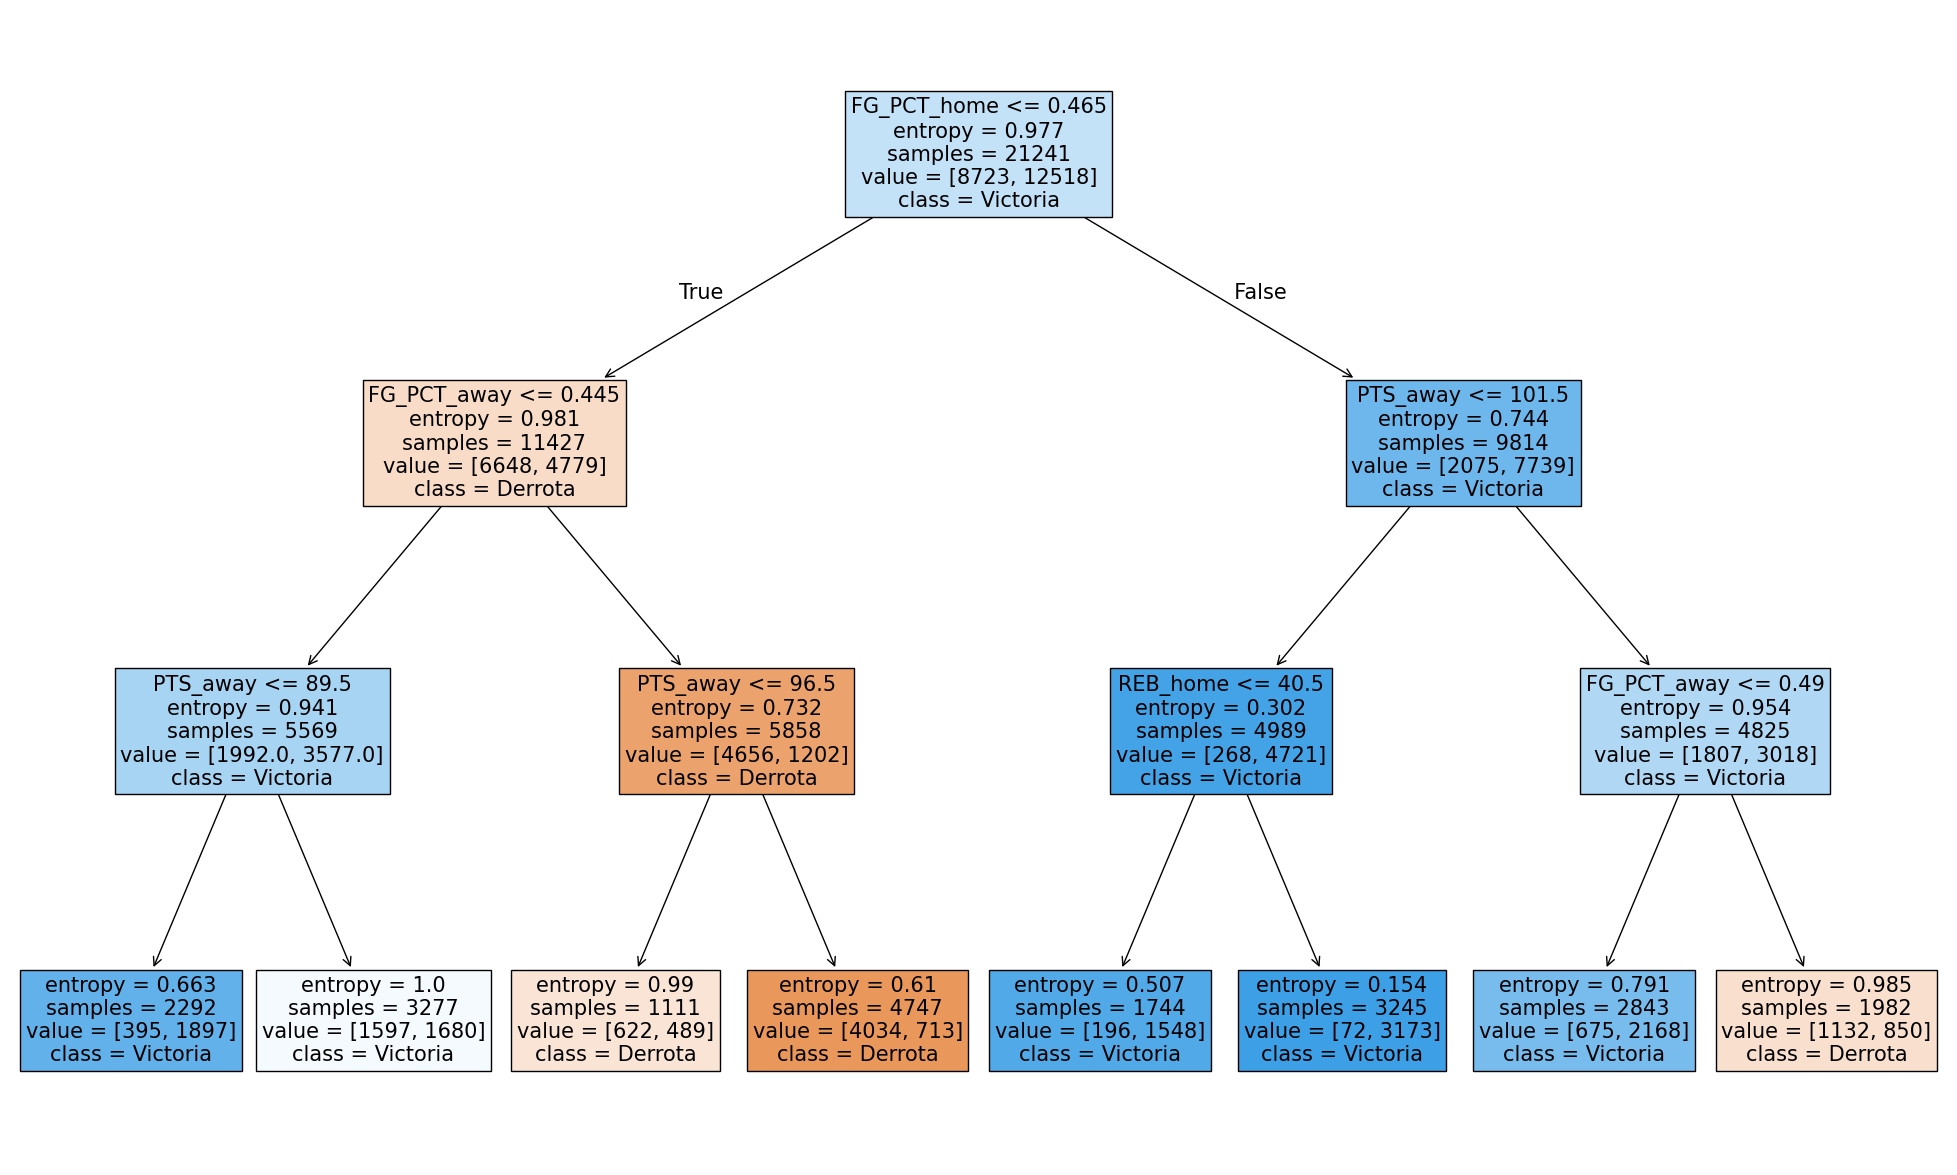

In [88]:
plt.figure(figsize=(25,15))
plot_tree(tree1, feature_names=X1.columns, class_names=['Derrota','Victoria'], filled=True,fontsize=15)
plt.show()

plt.figure(figsize=(25,15))
plot_tree(tree2, feature_names=X2.columns, class_names=['Derrota','Victoria'], filled=True,fontsize=15)
plt.show()

Algo que puede ser de ayuda es ver cuánto peso ha tenido cada variable a la hora de hacer nuestro Decision Tree. Veámoslo:

In [89]:
importances1 = pd.Series(tree1.feature_importances_, index=X1.columns)
print(importances1.sort_values(ascending=False))


importances2 = pd.Series(tree2.feature_importances_, index=X2.columns)
print(importances2.sort_values(ascending=False))

FG_PCT_away     0.478228
FG_PCT_home     0.348063
PTS_home        0.173709
FT_PCT_home     0.000000
FG3_PCT_home    0.000000
AST_home        0.000000
REB_home        0.000000
FT_PCT_away     0.000000
FG3_PCT_away    0.000000
AST_away        0.000000
REB_away        0.000000
dtype: float64
FG_PCT_home     0.351454
FG_PCT_away     0.326289
PTS_away        0.302803
REB_home        0.019454
FT_PCT_home     0.000000
AST_home        0.000000
FG3_PCT_home    0.000000
FT_PCT_away     0.000000
FG3_PCT_away    0.000000
AST_away        0.000000
REB_away        0.000000
dtype: float64


Para verlo más claro, vamos a hacer un gráfico de barras con la importancia de cada variable, así será más fácil poder sacar conclusiones.

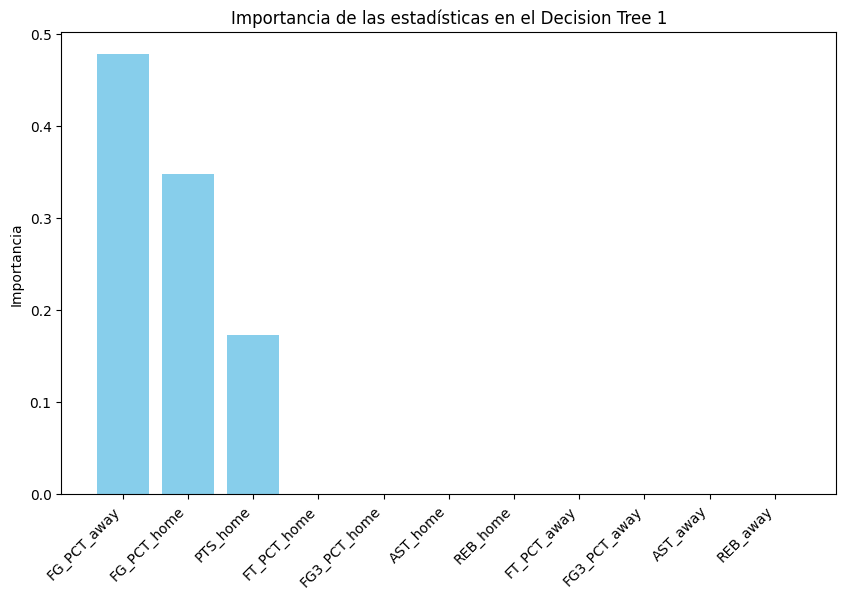

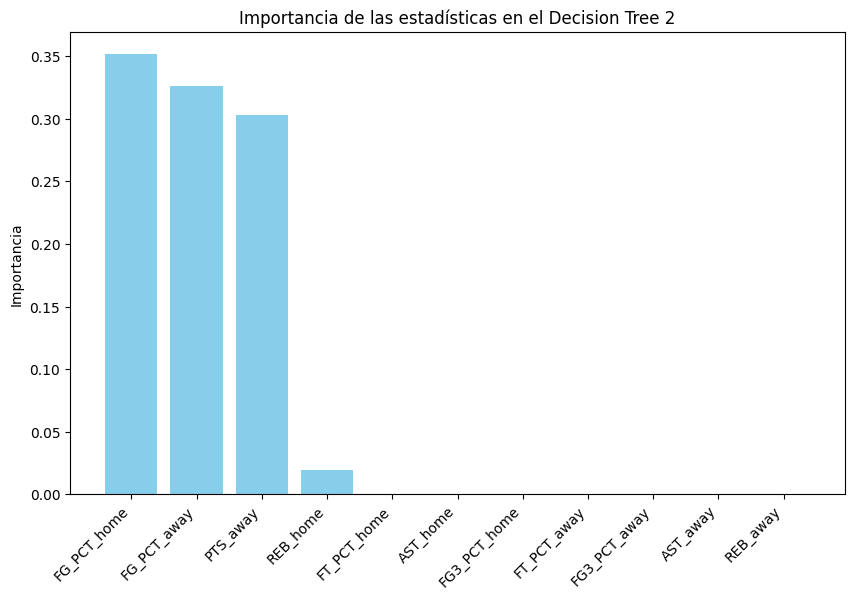

In [90]:
importances_sorted1 = importances1.sort_values(ascending=False)
plt.figure(figsize=(10,6))
plt.bar(importances_sorted1.index, importances_sorted1.values, color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Importancia')
plt.title('Importancia de las estadísticas en el Decision Tree 1')
plt.show()


importances_sorted2 = importances2.sort_values(ascending=False)
plt.figure(figsize=(10,6))
plt.bar(importances_sorted2.index, importances_sorted2.values, color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Importancia')
plt.title('Importancia de las estadísticas en el Decision Tree 2')
plt.show()

Lo primero que llama la atención es que solo está teniendo en cuenta 3 o 4 variables. Simplemente se debe a la profundidad que se le ha dado al Decision Tree al principio: max_depth=3. Cambiando este valor a 10 ya tiene en cuenta todas las variables, aumentando también la precisión de la predicción, pero el gráfico del árbol pasa a ser ilegible, por eso se presenta de esta forma.

Haciendo un breve análisis de las variables, aunque en cada caso cambian las importancias, la más importante parece ser el porcentaje de acierto de los tiros tanto del equipo local como visitante, lo cual tiene bastante sentido ya que en cierta medida un mayor porcentaje indica un mayor número de puntos anotados teniendo en cuenta que se suelen lanzar más o menos el mismo número de tiros.

# 6. REGRESIÓN LOGÍSTICA

Vamos a trabajar ahora con otra herramienta que nos permite predecir un resultado que solo puede tomar dos valores, por lo que se adapta a nuestro objetivo (predecir la victoria o derrota del equipo local en función a las estadísticas del partido).

Lo primero de todo, al igual que en el Decision Tree, debemos crear dos variables: una variable X donde incluiremos todas las estadísticas que pueden influír en el resultado y que queremos que analice nuestro programa; y una variable y que será el objetivo que queremos conocer, victoria o derrota del equipo local.

In [91]:
X1 = df1[['PTS_home', 'FG_PCT_home', 'FT_PCT_home', 'FG3_PCT_home', 
        'AST_home', 'REB_home',
        'FG_PCT_away', 'FT_PCT_away', 'FG3_PCT_away', 
        'AST_away', 'REB_away']]
y1 = df1['HOME_TEAM_WINS']

De nuevo igual que en el Decision Tree debemos entrenar nuestra regresión con una gran parte de nuestros datos (80% de ellos) y a continuación predeciremos el resultado del 20% restante y lo compararemos con el resultado real, lo que nos permetirá hacer un pequeño estudio de lo preciso que es el programa.

Precisión: 0.8695160986631519

Matriz de confusión:
 [[1809  375]
 [ 318 2809]]

Informe de clasificación:
               precision    recall  f1-score   support

           0       0.85      0.83      0.84      2184
           1       0.88      0.90      0.89      3127

    accuracy                           0.87      5311
   macro avg       0.87      0.86      0.86      5311
weighted avg       0.87      0.87      0.87      5311



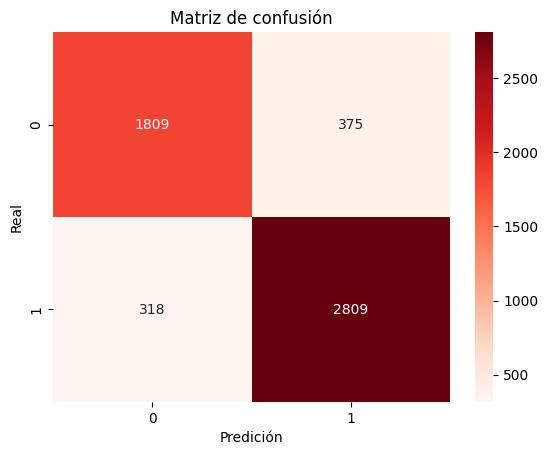

In [92]:
# entrenamos nuestro programa
X_train, X_test, y_train, y_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

# predecimos los resultados
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


# vemos cuánto se asemejan a la realidad

print("Precisión:", accuracy_score(y_test, y_pred))
print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred))
print("\nInforme de clasificación:\n", classification_report(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds")
plt.xlabel("Predición")
plt.ylabel("Real")
plt.title("Matriz de confusión")
plt.show()

Vemos que el resultado es más preciso que en el Decision Tree aunque ligeramente, sobre un 86,9%. La matriz de confusión por su parte nos muestra que el programa detecta de forma notablemente mejor la victoria que la derrota.

# 7. CONCLUSIÓN

Tras comparar los tres modelos utilizados, todos tienen una precisión entre el 75% y el 87%, siendo el mejor la Regresión Logística. El peor resultado obtenido fue el del Decision Tree pero, como se explicó anteriormente, esto es debido a la elección de un 'max_depth=3' para poder hacer el gráfico legible, a costo de no tener en cuenta todas las variables.